<a href="https://colab.research.google.com/github/Mrclla-43/Eksplorasi-n-Visualisasi-Data/blob/main/Tugas%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analisis Deteksi Outlier Menggunakan Boxplot serta Ukuran Pemusatan dan Penyebaran Data pada Dataset Titanic** ##

Dataset yang digunakan dalam analisis ini adalah dataset Titanic yang tersedia langsung melalui library seaborn, sehingga tidak perlu melakukan proses download data secara manual. Dataset ini diambil dari : Kaggle.

Variabel yang digunakan:
1. Age → umur penumpang
2. Fare → harga tiket
3. Pclass → kelas penumpang
4. Sex → jenis kelamin
5. Survived → status selamat

Fokus deteksi outlier:
- Age
- Fare

### **Load Data** ###

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


###  **Ukuran Pemusatan dan Penyebaran Data** ###

In [16]:
import numpy as np

# Ukuran pemusatan
mean_age = df['age'].mean()
median_age = df['age'].median()

mean_fare = df['fare'].mean()
median_fare = df['fare'].median()

# Ukuran penyebaran
std_age = df['age'].std()
var_age = df['age'].var()

std_fare = df['fare'].std()
var_fare = df['fare'].var()


# Kuartil untuk AGE
Q1_age = df['age'].quantile(0.25)
Q2_age = df['age'].quantile(0.50)  # median
Q3_age = df['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# Kuartil untuk FARE
Q1_fare = df['fare'].quantile(0.25)
Q2_fare = df['fare'].quantile(0.50)  # median
Q3_fare = df['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

print("AGE")
print("Mean:", mean_age)
print("Median:", median_age)
print("Standar Deviasi:", std_age)
print("Varians:", var_age)

print("\nFARE")
print("Mean:", mean_fare)
print("Median:", median_fare)
print("Standar Deviasi:", std_fare)
print("Varians:", var_fare)

# Tampilkan hasil
print("\nAGE")
print("Q1:", Q1_age)
print("Q2 (Median):", Q2_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)

print("\nFARE")
print("Q1:", Q1_fare)
print("Q2 (Median):", Q2_fare)
print("Q3:", Q3_fare)
print("IQR:", IQR_fare)


AGE
Mean: 29.69911764705882
Median: 28.0
Standar Deviasi: 14.526497332334044
Varians: 211.0191247463081

FARE
Mean: 32.204207968574636
Median: 14.4542
Standar Deviasi: 49.693428597180905
Varians: 2469.436845743117

AGE
Q1: 20.125
Q2 (Median): 28.0
Q3: 38.0
IQR: 17.875

FARE
Q1: 7.9104
Q2 (Median): 14.4542
Q3: 31.0
IQR: 23.0896


### **Visualisasi Boxplot** ###

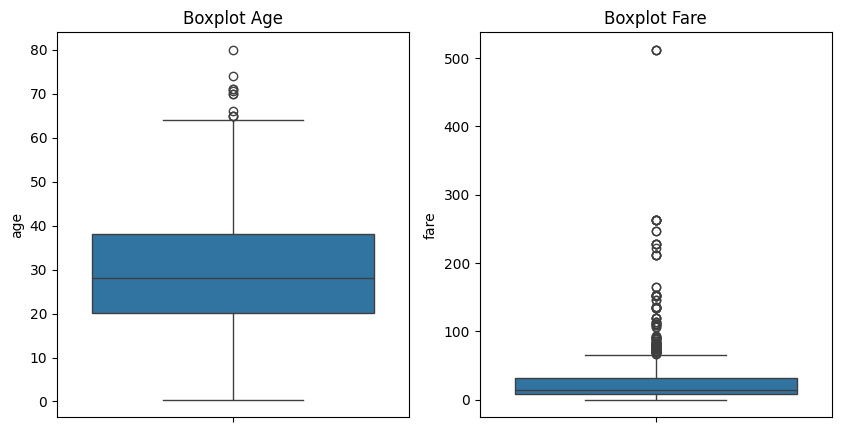

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['age'])
plt.title('Boxplot Age')

plt.subplot(1,2,2)
sns.boxplot(y=df['fare'])
plt.title('Boxplot Fare')

plt.show()

Berdasarkan hasil visualisasi boxplot dan perhitungan kuartil, dapat diketahui bahwa terdapat beberapa data yang berada di luar batas whisker yang menunjukkan adanya outlier, dengan rincian sebagai berikut:

1. Variabel Age
- Q1 ≈ 20.12
- Median (Q2) ≈ 28
- Q3 ≈ 38
- IQR ≈ 17.87

Interpretasi:

- Sebagian besar umur penumpang berada di rentang 20 – 38 tahun
- Batas atas outlier berada di sekitar > 65 tahun
- Terlihat beberapa titik di atas batas tersebut → menunjukkan adanya outlier (usia sangat tinggi)

2. Variabel Fare
- Q1 ≈ 7.91
- Median (Q2) ≈ 14.45
- Q3 ≈ 31
- IQR ≈ 23.08

Interpretasi:

- Sebagian besar harga tiket berada di rentang 7.9 – 31
- Batas atas outlier berada di sekitar > 65
- Terlihat banyak titik jauh di atas whisker → menunjukkan banyak outlier. Bahkan terdapat nilai ekstrem hingga > 500

Nilai-nilai di atas merupakan hasil pendekatan dari visualisasi dan perhitungan, sehingga dapat sedikit berbeda tergantung hasil komputasi pada program yang dijalankan.

### **IQR (Deteksi Outlier)** ###

In [7]:
# Menghitung batas outlier pada fare
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan outlier
outliers = df[(df['fare'] < Q1 - 1.5*IQR) | (df['fare'] > Q3 + 1.5*IQR)]

# Tampilkan hasil
outliers[['fare']]

,fare
1,71.2833
27,263.0000
31,146.5208
34,82.1708
52,76.7292
...,...
846,69.5500
849,89.1042
856,164.8667
863,69.5500


Berdasarkan hasil analisis menggunakan boxplot dan metode IQR, ditemukan adanya beberapa data yang tergolong sebagai outlier pada variabel fare dan age. Outlier merupakan data yang memiliki nilai jauh berbeda dibandingkan mayoritas data lainnya.

Adapun rincian outlier yang ditemukan adalah sebagai berikut:

1. Variabel Fare

Variabel fare menunjukkan adanya nilai yang sangat tinggi dibandingkan sebagian besar data.

- Nilai normal berada pada kisaran 0 hingga 100
- Ditemukan outlier dengan nilai lebih dari 500
- Outlier ini menunjukkan adanya penumpang dengan harga tiket sangat mahal.
Hal ini kemungkinan berasal dari penumpang kelas atas (kelas 1)

2. Variabel Age

Variabel age juga memiliki beberapa nilai yang tergolong outlier.

- Nilai normal berada pada kisaran 0 hingga 60 tahun
- Ditemukan outlier dengan usia di atas 70 tahun
- Nilai ini tergolong jarang dibandingkan mayoritas penumpang.
Outlier ini masih mungkin valid karena bisa merupakan penumpang lansia